# Introduction

This analysis explores a dataset focused on teenage mental health and social media usage patterns. The objective is to understand how factors such as daily social media usage, platform preference, gender, and behavioral traits relate to mental well-being.

Using Python libraries like Pandas, NumPy, Matplotlib, and Seaborn, the dataset will be cleaned, explored, and visualized to identify trends, patterns, and potential correlations. The goal is to extract meaningful insights that can help in understanding the impact of social media on mental health and guide further analysis.

# Data Loading & Initial Inspection

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
content = pd.read_csv("/kaggle/input/datasets/algozee/teenager-menthal-healy/Teen_Mental_Health_Dataset.csv")
content.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [13]:
content.tail()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0
1199,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,7,3,0


In [14]:
content.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [15]:
content.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## Distribution of Daily Social Media Usage by Gender

<Axes: xlabel='daily_social_media_hours', ylabel='Count'>

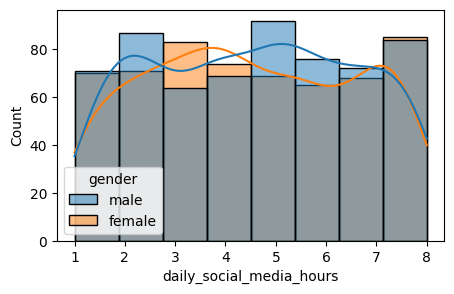

In [16]:
fig, axes = plt.subplots(1,1, figsize = (5,3))
sns.histplot(data = content,  x= "daily_social_media_hours", 
             hue = "gender", kde = True, bins = 8)

In [17]:
data = content.groupby("gender").daily_social_media_hours.mean()
data

gender
female    4.512991
male      4.559187
Name: daily_social_media_hours, dtype: float64

Results are almost similar, the difference is small. Will look to uncover hidden insights. This feature will be explored further.


## Platform Usage


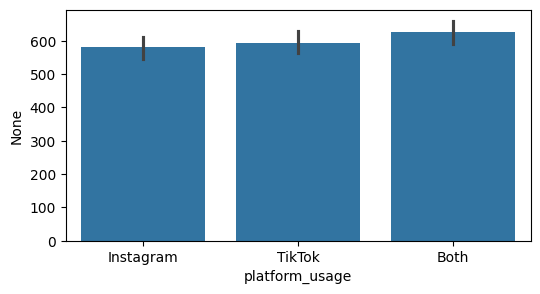

In [18]:
plt.figure(figsize = (6,3))
sns.barplot(data=content, x='platform_usage', y=content.index)
plt.show()

Platform usage shows very similar distribution across users. Not a strong factor, so it will not be prioritized in further EDA.


# Here begins the EDA section

## Distribution of different Behaviours vs Age

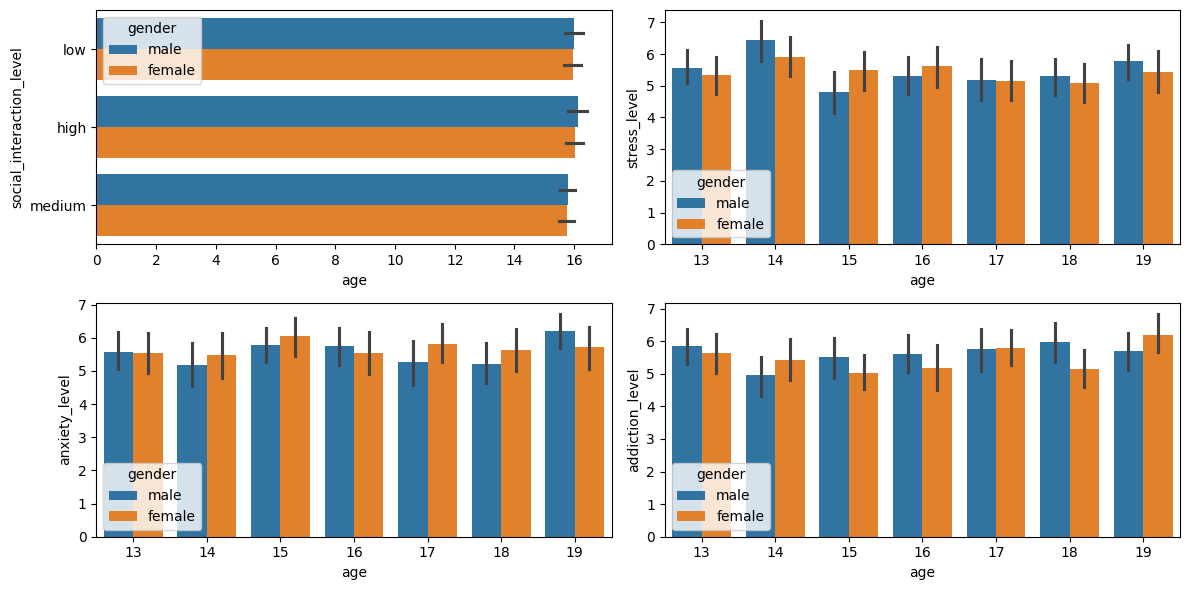

In [19]:
content.daily_social_media_hours = content.daily_social_media_hours.astype("int")
selected_columns = ["social_interaction_level", "stress_level", "anxiety_level", "addiction_level"]
fig, axes = plt.subplots(2, 2, figsize=(12,6))
for i, col in enumerate(selected_columns):
    r = i // 2
    c = i % 2
    sns.barplot(data=content, x="age", y=col, ax=axes[r][c], hue="gender")
plt.tight_layout()
plt.show()

The analysis suggests that males tend to exhibit slightly higher stress and addiction levels compared to females, particularly at higher levels of social media usage. However, anxiety levels and social media usage itself do not show a consistent or significant difference between genders, indicating that these factors are relatively similar across both groups.

## Comparison of Individual who are Depressed vs Not

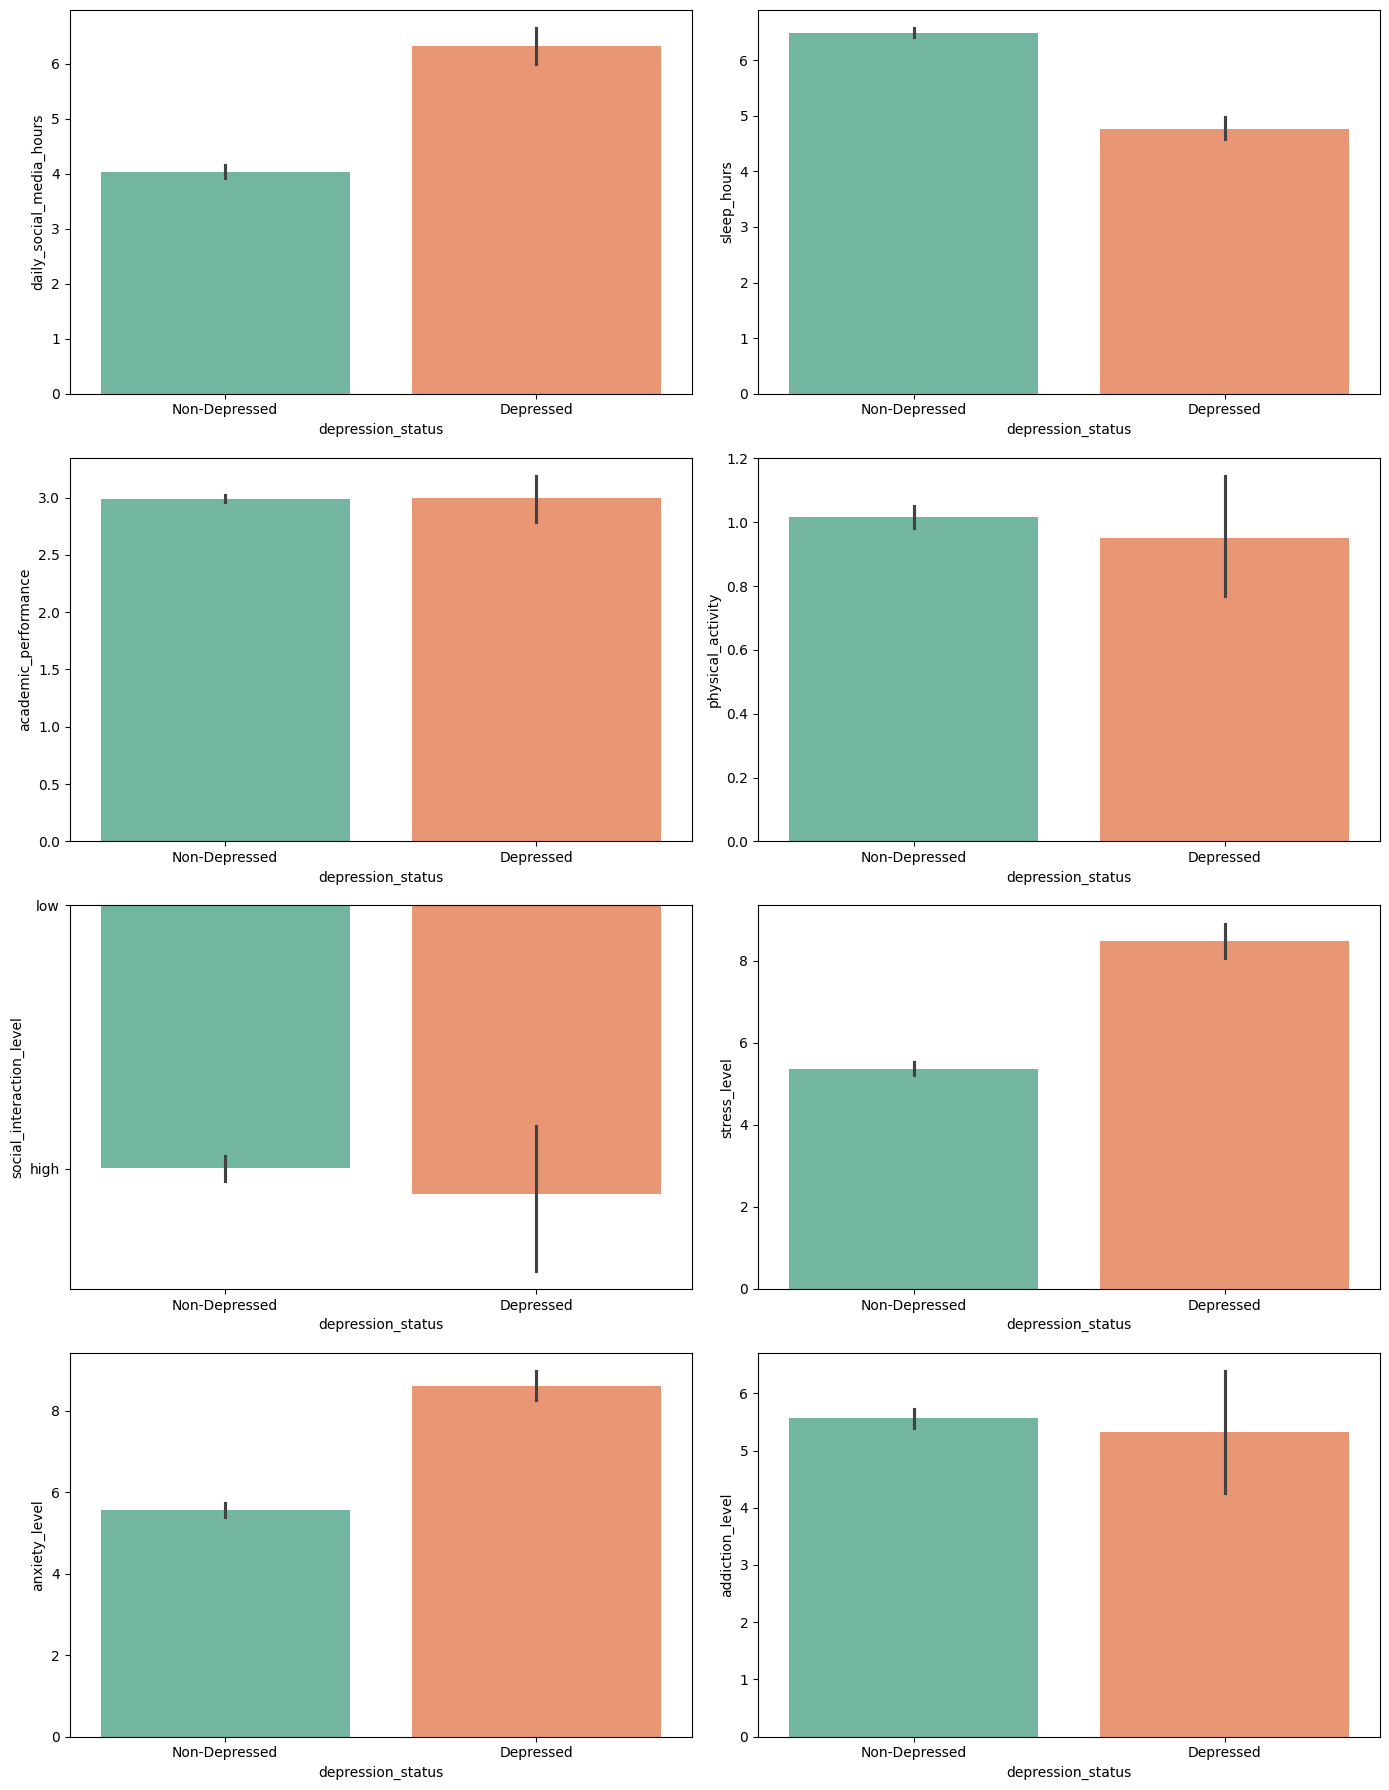

In [20]:
content["depression_status"] = content["depression_label"].map({
    0: "Non-Depressed",
    1: "Depressed"
})
cols = content.columns[content.columns.str.contains("level|hours|academic|activity", case=False)].tolist()
fig, axes = plt.subplots(4, 2, figsize=(14,18))
for i, col in enumerate(cols):
    r = i // 2
    c = i % 2
    sns.barplot(data=content, x="depression_status", y=col, ax=axes[r][c], palette= "Set2",
               hue = "depression_status")
plt.tight_layout()
plt.show()

**Social Media Usage**

1. Depressed individuals spend significantly more time on social media
2. Suggests possible overuse or coping behavior
   
**Sleep Hours**
1. Depressed individuals have lower average sleep hours
2. Indicates poor sleep patterns or disturbances
   
**Screen Time Before Sleep**

1. Slightly higher or inconsistent for depressed individuals
2. Can contribute to poor sleep quality
   
**Physical Activity**
1. Depressed individuals show lower physical activity levels
2. Strongly linked with mental health decline
   
**Academic Performance**

1. Slight difference, but not dramatic
2. Depression may impact performance, but not always directly
   
**Stress Levels**
1. Depressed individuals have much higher stress levels
2. One of the strongest differences in your plots
   
**Anxiety Levels**
1. Clearly higher in depressed individuals
2. Expected, but your data confirms it strongly
   
**Addiction Levels**
1. Slightly lower or mixed trend, not very strong
2. Weak relationship compared to others

> Individuals with depression tend to exhibit higher stress and anxiety levels, lower sleep and physical activity, and increased social media usage, indicating a strong association between mental health and lifestyle behaviors.

# Final Conclusion

This analysis reveals that mental health among teenagers is strongly influenced by factors like stress, anxiety, sleep, and physical activity. Depressed individuals tend to show higher stress and anxiety levels along with poorer lifestyle habits.

In contrast, features such as gender, platform usage, and addiction level did not show significant differences, indicating they are less impactful.

Overall, the study highlights that mental health is driven more by behavioral and lifestyle factors, and that tools like Pandas, Matplotlib, and Seaborn are just a means—the real value lies in interpreting the data effectively.

# About the Author

Divyansh Sharma

This notebook represents my first serious attempt at Exploratory Data Analysis (EDA). As a beginner, this project helped me understand not just how to use tools like Pandas, Matplotlib, and Seaborn, but more importantly how to think with data.

Through this analysis, I learned that simply knowing functions and libraries is not enough—what truly matters is how we apply them to extract meaningful insights. This experience pushed me to move beyond just plotting graphs and start interpreting patterns, questioning results, and forming conclusions.

Overall, this project has been a strong step in building my foundation in data analysis and has motivated me to keep improving and exploring further.

LinkedIn: [https://www.linkedin.com/in/divyansh-sharma-5546b3223/]